# RNN Day 1 Housing Data

### Importing Libraries

In [40]:
import pandas as pd                                 # table/dataframe handling
import numpy as np                                  # numerical operations
import matplotlib.pyplot as plt                     # plotting

from sklearn.preprocessing import MinMaxScaler      # scales values to 0-1 range
from sklearn.metrics import mean_absolute_error, mean_squared_error 
                                                    # RMSE and MAE calculation

import tensorflow as tf
import random

from tensorflow.keras.models import Sequential      # sequential neural network API

from tensorflow.keras.layers import (
    Dense,                                          # standard fully connected layer
    SimpleRNN,                                      # recurrent neural network layer
    Conv1D,                                         # 1D convolution layer
    Flatten                                         # flatten multidimensional output
)

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

### Loading the data

In [41]:
house = pd.read_csv("C:\\Users\\2003n\\OneDrive - Cal Poly\\Desktop\\ma_lga_12345.csv")   # load housing dataset

house.head()                              # inspect first few rows

,saledate,MA,type,bedrooms
0,30/09/2007,441854,house,2
1,31/12/2007,441854,house,2
2,31/03/2008,441854,house,2
3,30/06/2008,441854,house,2
4,30/09/2008,451583,house,2


### Inspecting the temporal nature of the data

In [42]:
print(house.shape)            # number of rows and columns
print(house.dtypes)           # variable data types
print(house.isna().sum())     # missing values per column

house.describe()              # summary statistics

(347, 4)
saledate    object
MA           int64
type        object
bedrooms     int64
dtype: object
saledate    0
MA          0
type        0
bedrooms    0
dtype: int64


,MA,bedrooms
count,3.470000e+02,347.000000
mean,5.481320e+05,2.867435
std,1.701934e+05,1.239875
min,3.167510e+05,1.000000
25%,4.277395e+05,2.000000
50%,5.077440e+05,3.000000
75%,6.275155e+05,4.000000
max,1.017752e+06,5.000000


## Defining useful functions


Formatting data for rolling windows

In [43]:
def create_sequences(dataset, look_back=2):

    X, y = [], []                          # containers for windows and targets

    for i in range(len(dataset) - look_back):

        X.append(dataset[i:i + look_back, :])   # rolling window
        y.append(dataset[i + look_back, 0])     # next timestep target

    return np.array(X), np.array(y)

Plotting training curves

In [44]:
def plot_training_curves(history, title):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history["loss"], label="Training Loss")
    axes[0].plot(history.history["val_loss"], label="Validation Loss")
    axes[0].set_title(title + " Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE Loss")
    axes[0].set_ylim(0, 0.4)
    axes[0].legend()

    axes[1].plot(history.history["mean_absolute_error"], label="Training MAE")
    axes[1].plot(history.history["val_mean_absolute_error"], label="Validation MAE")
    axes[1].set_title(title + " MAE")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Mean Absolute Error")
    axes[1].set_ylim(0, 0.65)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

Evaluating model performance on test data

In [45]:
def evaluate_and_plot(model, trainX, testX, trainY, testY, scaler, title):

    # Make predictions
    train_pred = model.predict(trainX)
    test_pred = model.predict(testX)

    # Convert scaled values back to original MA scale
    train_pred_inv = scaler.inverse_transform(train_pred)
    test_pred_inv = scaler.inverse_transform(test_pred)
    trainY_inv = scaler.inverse_transform(trainY.reshape(-1, 1))
    testY_inv = scaler.inverse_transform(testY.reshape(-1, 1))

    # Calculate RMSE on original scale
    train_rmse = np.sqrt(mean_squared_error(trainY_inv, train_pred_inv))
    test_rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))

    print(f"{title} Train RMSE: {train_rmse:.2f}")
    print(f"{title} Test RMSE: {test_rmse:.2f}")

    # Plot held-out future test predictions
    plt.figure(figsize=(10, 4))
    plt.plot(testY_inv, label="Actual")
    plt.plot(test_pred_inv, label="Predicted")

    plt.title(title + " Test Predictions")
    plt.xlabel("Test time index")
    plt.ylabel("MA")
    plt.ylim(0, 1200000)
    plt.ticklabel_format(style="plain", axis="y")
    plt.legend()
    plt.show()

Comparing forcasting performance metrics

In [46]:

def evaluate_metrics(model, testX, testY, scaler):

    test_pred = model.predict(testX)

    test_pred_inv = scaler.inverse_transform(test_pred)
    testY_inv = scaler.inverse_transform(testY.reshape(-1, 1))

    rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))
    mae = mean_absolute_error(testY_inv, test_pred_inv)

    return rmse, mae

### Initial RNN & Performance

In [47]:
# Initial RNN

ma_sequence = house.copy()
ma_sequence = ma_sequence.sort_values("saledate").reset_index(drop=True)
                                                                # preserve chronological order

df_initial = ma_sequence[["MA"]].copy()                         # univariate forecasting feature

scaler_initial = MinMaxScaler(feature_range=(0, 1))
scaled_initial = scaler_initial.fit_transform(df_initial)
                                                                # neural networks train better on scaled values

look_back = 2                                                   # use previous 2 timesteps to predict next timestep

train_size = int(len(scaled_initial) * 0.8)

train_initial = scaled_initial[:train_size]                     # earlier historical data
test_initial = scaled_initial[train_size:]                      # held-out future data

trainX_initial, trainY_initial = create_sequences(
    train_initial,
    look_back
)                                                               # rolling training windows

testX_initial, testY_initial = create_sequences(
    test_initial,
    look_back
)                                                               # rolling future test windows

print("trainX shape:", trainX_initial.shape)
print("testX shape:", testX_initial.shape)

initial_model = Sequential([
    SimpleRNN(
        16,
        activation="tanh",
        input_shape=(look_back, trainX_initial.shape[2])
    ),                                                          # recurrent hidden layer

    Dense(1)                                                    # regression output layer
])

initial_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

initial_history = initial_model.fit(
    trainX_initial,
    trainY_initial,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,                                              # preserve temporal order
    verbose=1
)

trainX shape: (275, 2, 1)
testX shape: (68, 2, 1)
Epoch 1/100


c:\Users\2003n\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.1027 - mean_absolute_error: 0.2647 - val_loss: 0.0916 - val_mean_absolute_error: 0.2549
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0868 - mean_absolute_error: 0.2409 - val_loss: 0.0807 - val_mean_absolute_error: 0.2324
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0758 - mean_absolute_error: 0.2230 - val_loss: 0.0740 - val_mean_absolute_error: 0.2187
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0682 - mean_absolute_error: 0.2089 - val_loss: 0.0702 - val_mean_absolute_error: 0.2103
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0633 - mean_absolute_error: 0.1992 - val_loss: 0.0686 - val_mean_absolute_error: 0.2046
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0602 - mean_absolute_error: 0.1938 - val_loss: 0.0682 - val_mean_absolute_error: 0.2039
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0583 - mean_absolute_error: 0.1910 - val_loss: 0.068

Training curves

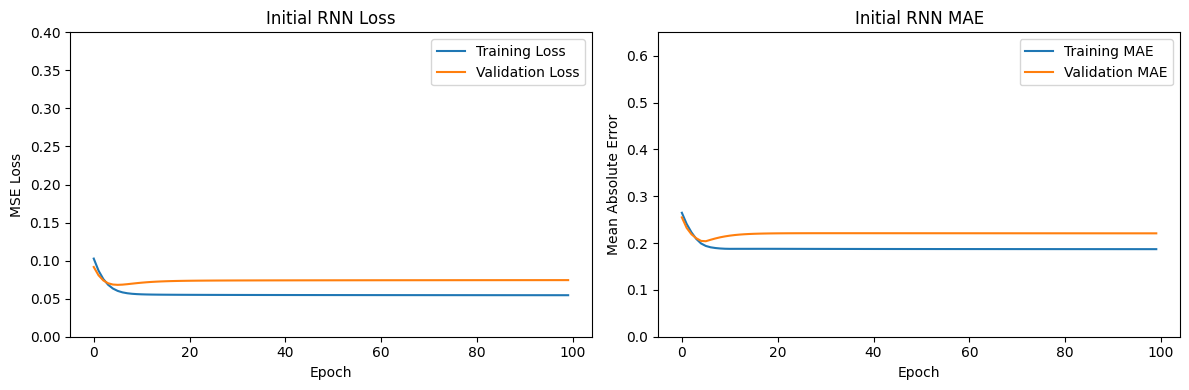

In [48]:
plot_training_curves(
    initial_history,
    "Initial RNN"
)

Test data evaluation

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Initial RNN Train RMSE: 168752.01
Initial RNN Test RMSE: 171397.52


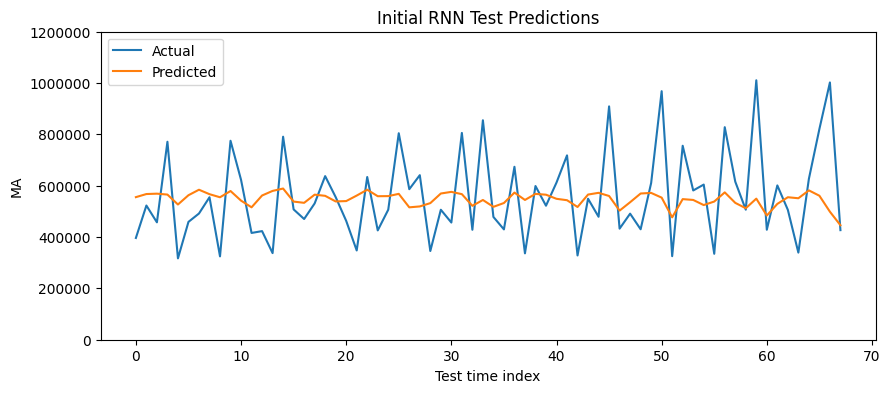

In [49]:
evaluate_and_plot(
    initial_model,
    trainX_initial,
    testX_initial,
    trainY_initial,
    testY_initial,
    scaler_initial,
    "Initial RNN"
)

### Initial MA data re-evaluation

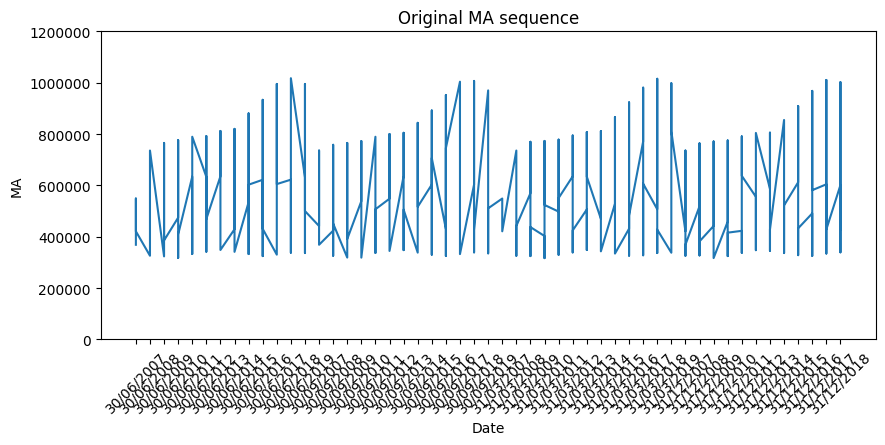

In [50]:
# Plot the original MA sequence exactly as provided

plt.figure(figsize=(10, 4))

plt.plot(
    ma_sequence["saledate"],
    ma_sequence["MA"]
)

plt.title("Original MA sequence")
plt.xlabel("Date")
plt.ylabel("MA")

plt.ylim(0, 1200000)

plt.ticklabel_format(
    style='plain',
    axis='y'
)                                        

plt.xticks(rotation=45)

plt.show()


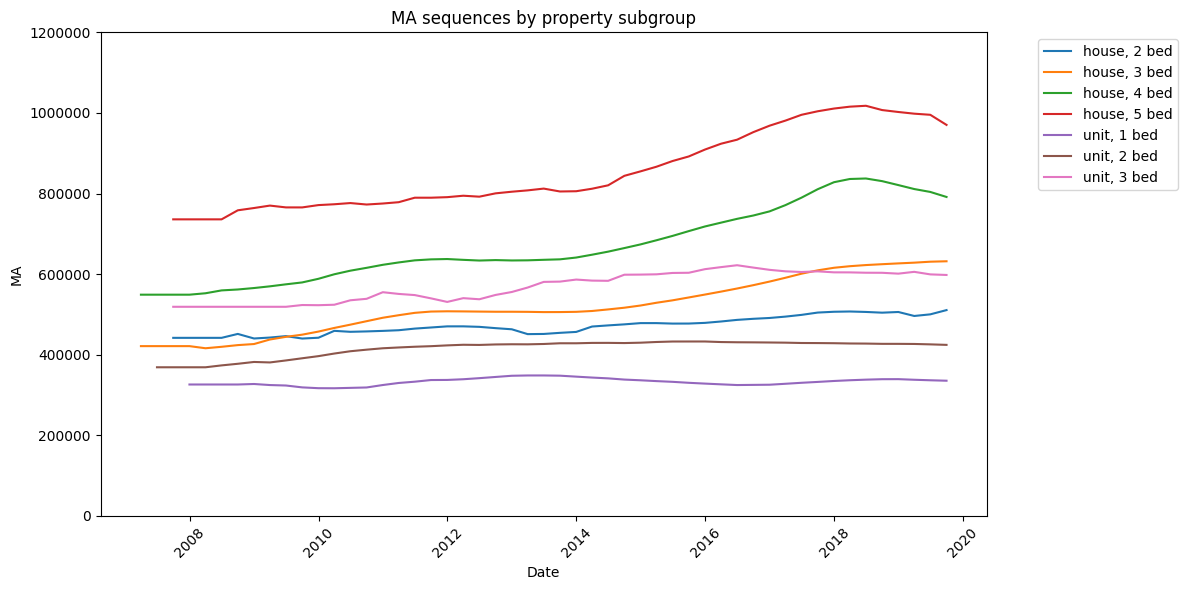

In [51]:
# Plot each subgroup MA sequence separately

house["saledate"] = pd.to_datetime(
    house["saledate"],
    dayfirst=True
)

# Plot each subgroup MA sequence separately

house["saledate"] = pd.to_datetime(
    house["saledate"],
    dayfirst=True
)

plt.figure(figsize=(12, 6))

for (property_type, bedrooms), group in house.groupby(["type", "bedrooms"]):

    group = group.sort_values("saledate")      # chronological ordering

    plt.plot(
        group["saledate"],
        group["MA"],
        label=f"{property_type}, {bedrooms} bed"
    )

plt.title("MA sequences by property subgroup")

plt.xlabel("Date")
plt.ylabel("MA")

plt.ylim(0, 1200000)

plt.ticklabel_format(
    style='plain',
    axis='y'
)

plt.xticks(rotation=45)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

Inspecting the first window

In [52]:
print("trainX_initial shape:", trainX_initial.shape)

window_id = 0

ma_sequence.iloc[
    window_id : window_id + look_back + 1
][["saledate", "type", "bedrooms", "MA"]]

trainX_initial shape: (275, 2, 1)


,saledate,type,bedrooms,MA
0,30/06/2007,unit,2,368817
1,30/06/2007,house,4,548969
2,30/06/2007,house,3,421291


### Creating market-level MA data

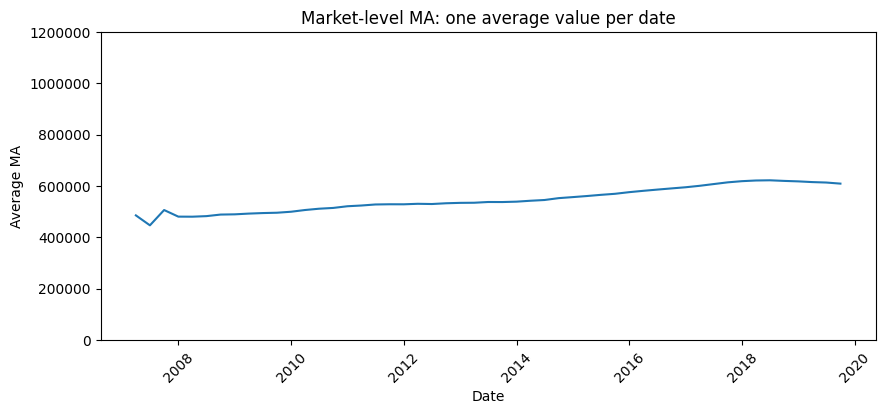

In [53]:
# Create market-level MA sequence

house["saledate"] = pd.to_datetime(
    house["saledate"],
    dayfirst=True
)                                                    # ensure dates sort chronologically

market_ma = (
    house
    .groupby("saledate")["MA"]
    .mean()
    .reset_index()
    .sort_values("saledate")
    .reset_index(drop=True)
)                                                    # average subgroup MAs per date

# Visualize market-level MA

plt.figure(figsize=(10, 4))

plt.plot(
    market_ma["saledate"],
    market_ma["MA"]
)

plt.title("Market-level MA: one average value per date")
plt.xlabel("Date")
plt.ylabel("Average MA")

plt.ylim(0, 1200000)
plt.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=45)

plt.show()

### Preparing market-level MA data for variety of models

In [54]:
# Prepare market-level MA data for all fixed-data models

df_market = market_ma[["MA"]].copy()                            # cleaned one-value-per-date MA series

scaler_market = MinMaxScaler(feature_range=(0, 1))              # scale MA values for neural networks
scaled_market = scaler_market.fit_transform(df_market)

look_back = 2                                                   # use 2 previous timesteps to predict next timestep

train_size = int(len(scaled_market) * 0.8)                      # chronological 80/20 split

train_market = scaled_market[:train_size]                       # earlier historical data
test_market = scaled_market[train_size:]                        # held-out future data

trainX_market, trainY_market = create_sequences(
    train_market,
    look_back
)                                                               # sequence windows for RNN/CNN

testX_market, testY_market = create_sequences(
    test_market,
    look_back
)                                                               # future test windows for RNN/CNN

trainX_market_mlp = trainX_market.reshape(
    trainX_market.shape[0],
    trainX_market.shape[1] * trainX_market.shape[2]
)                                                               # flattened windows for MLP

testX_market_mlp = testX_market.reshape(
    testX_market.shape[0],
    testX_market.shape[1] * testX_market.shape[2]
)                                                               # flattened test windows for MLP

print("RNN/CNN trainX_market shape:", trainX_market.shape)
print("RNN/CNN testX_market shape:", testX_market.shape)

print("MLP trainX_market_mlp shape:", trainX_market_mlp.shape)
print("MLP testX_market_mlp shape:", testX_market_mlp.shape)

RNN/CNN trainX_market shape: (38, 2, 1)
RNN/CNN testX_market shape: (9, 2, 1)
MLP trainX_market_mlp shape: (38, 2)
MLP testX_market_mlp shape: (9, 2)


### Inspecting the tensors

Shape & window 0 values

In [55]:
print("trainX_market shape:", trainX_market.shape)

window_id = 0

market_ma.iloc[
    window_id : window_id + look_back + 1
][["saledate", "MA"]]

trainX_market shape: (38, 2, 1)


,saledate,MA
0,2007-03-31,485130.000000
1,2007-06-30,446359.000000
2,2007-09-30,505957.666667


Scale window 0

In [56]:
# Visualize one input window and its target

window_id = 0

print("Input window:")
print(trainX_market[window_id].flatten())

print("Target:")
print(trainY_market[window_id])

Input window:
[0.22095731 0.        ]
Target:
0.33965492068299463


### Market-level RNN model & evaluation

In [57]:
# Build and train market-level RNN model

market_rnn_model = Sequential([
    SimpleRNN(
        16,
        activation="tanh",
        input_shape=(look_back, trainX_market.shape[2])
    ),
    Dense(1)
])

market_rnn_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

market_rnn_history = market_rnn_model.fit(
    trainX_market,
    trainY_market,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

Epoch 1/100


c:\Users\2003n\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - loss: 0.0500 - mean_absolute_error: 0.2169 - val_loss: 0.1204 - val_mean_absolute_error: 0.3453
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0223 - mean_absolute_error: 0.1427 - val_loss: 0.0597 - val_mean_absolute_error: 0.2425
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0068 - mean_absolute_error: 0.0768 - val_loss: 0.0229 - val_mean_absolute_error: 0.1492
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0017 - mean_absolute_error: 0.0272 - val_loss: 0.0061 - val_mean_absolute_error: 0.0754
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0028 - mean_absolute_error: 0.0423 - val_loss: 0.0013 - val_mean_absolute_error: 0.0306
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0049 - mean_absolute_error: 0.0608 - val_loss: 6.6129e-04 - val_mean_absolute_error: 0.0215
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0052 - mean_absolute_error: 0.0612 - val_loss: 0.0013 - val

Training curves

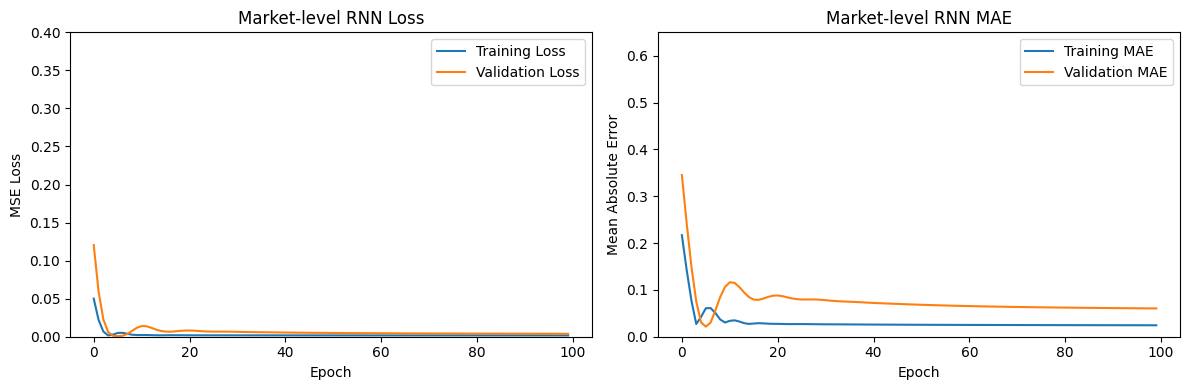

In [58]:
plot_training_curves(
    market_rnn_history,
    "Market-level RNN"
)

Test data evaluation

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
Market-level RNN Train RMSE: 8131.16
Market-level RNN Test RMSE: 15985.01


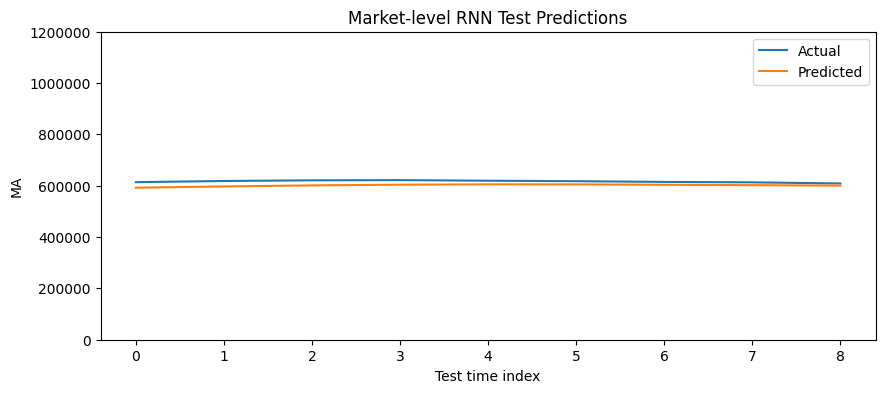

In [59]:
evaluate_and_plot(
    market_rnn_model,
    trainX_market,
    testX_market,
    trainY_market,
    testY_market,
    scaler_market,
    "Market-level RNN"
)

### Market level MLP and evaluation

In [60]:
# Build and train market-level MLP model

market_mlp_model = Sequential([
    Dense(
        32,
        activation="relu",
        input_shape=(trainX_market_mlp.shape[1],)
    ),
    Dense(
        16,
        activation="relu"
    ),
    Dense(1)
])

market_mlp_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

market_mlp_history = market_mlp_model.fit(
    trainX_market_mlp,
    trainY_market,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

Epoch 1/100


c:\Users\2003n\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 183ms/step - loss: 0.0963 - mean_absolute_error: 0.2989 - val_loss: 0.2720 - val_mean_absolute_error: 0.5195
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0762 - mean_absolute_error: 0.2646 - val_loss: 0.2254 - val_mean_absolute_error: 0.4728
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0604 - mean_absolute_error: 0.2341 - val_loss: 0.1870 - val_mean_absolute_error: 0.4305
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0456 - mean_absolute_error: 0.2016 - val_loss: 0.1498 - val_mean_absolute_error: 0.3851
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0322 - mean_absolute_error: 0.1670 - val_loss: 0.1146 - val_mean_absolute_error: 0.3366
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0213 - mean_absolute_error: 0.1330 - val_loss: 0.0845 - val_mean_absolute_error: 0.2888
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0130 - mean_absolute_error: 0.1011 - val_loss: 0.0601 - val_mea

Training curves MLP

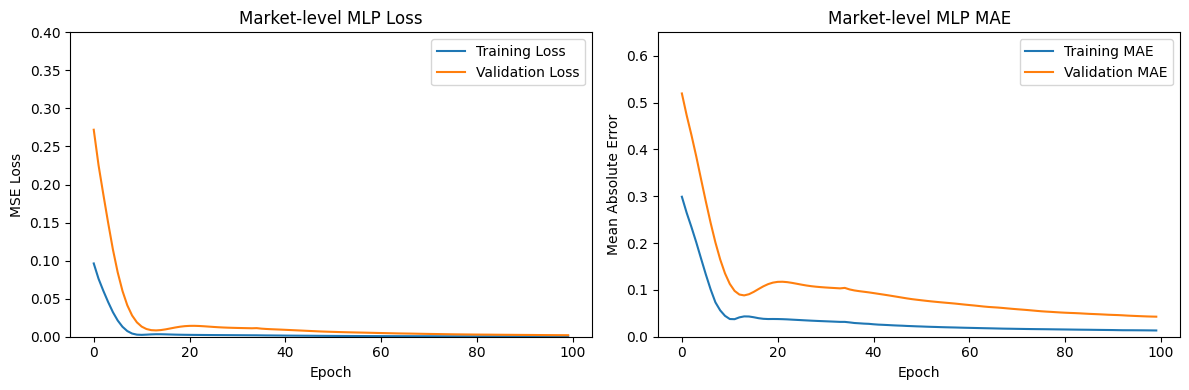

In [61]:
plot_training_curves(
    market_mlp_history,
    "Market-level MLP"
)

Test data evaluation MLP

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Market-level MLP Train RMSE: 4631.41
Market-level MLP Test RMSE: 10526.73


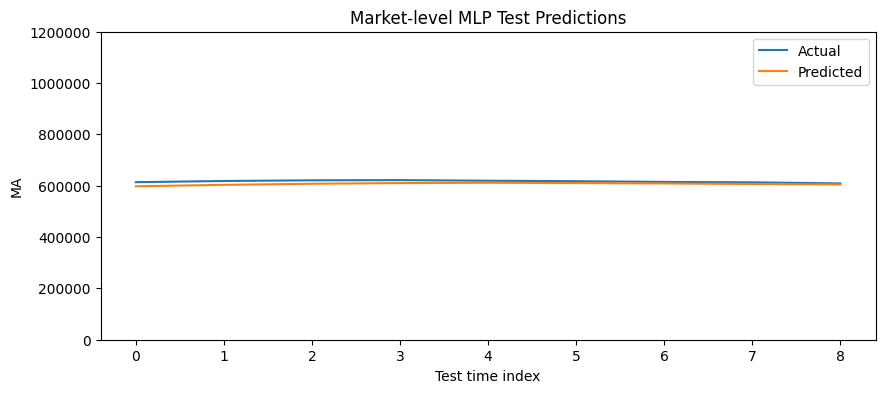

In [62]:
evaluate_and_plot(
    market_mlp_model,
    trainX_market_mlp,
    testX_market_mlp,
    trainY_market,
    testY_market,
    scaler_market,
    "Market-level MLP"
)

### Market level CNN & evaluation

In [63]:
# Build and train market-level 1D CNN model

market_cnn_model = Sequential([
    Conv1D(
        filters=16,                         # learn 16 temporal pattern detectors
        kernel_size=2,                      # each filter looks across 2 neighboring timesteps
        activation="relu",
        input_shape=(look_back, trainX_market.shape[2])
    ),                                      # input shape = timesteps, features

    Flatten(),                              # convert CNN output to flat vector for Dense layer

    Dense(1)                                # regression output layer
])

market_cnn_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

market_cnn_history = market_cnn_model.fit(
    trainX_market,
    trainY_market,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,                          # preserve temporal order
    verbose=1
)

Epoch 1/100


c:\Users\2003n\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 161ms/step - loss: 0.0999 - mean_absolute_error: 0.3029 - val_loss: 0.2975 - val_mean_absolute_error: 0.5433
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0884 - mean_absolute_error: 0.2840 - val_loss: 0.2710 - val_mean_absolute_error: 0.5184
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0778 - mean_absolute_error: 0.2656 - val_loss: 0.2458 - val_mean_absolute_error: 0.4937
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0681 - mean_absolute_error: 0.2474 - val_loss: 0.2222 - val_mean_absolute_error: 0.4693
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0592 - mean_absolute_error: 0.2297 - val_loss: 0.2003 - val_mean_absolute_error: 0.4455
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0514 - mean_absolute_error: 0.2127 - val_loss: 0.1801 - val_mean_absolute_error: 0.4224
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0445 - mean_absolute_error: 0.1967 - val_loss: 0.1618 - val_mea

Training curves 1D CNN

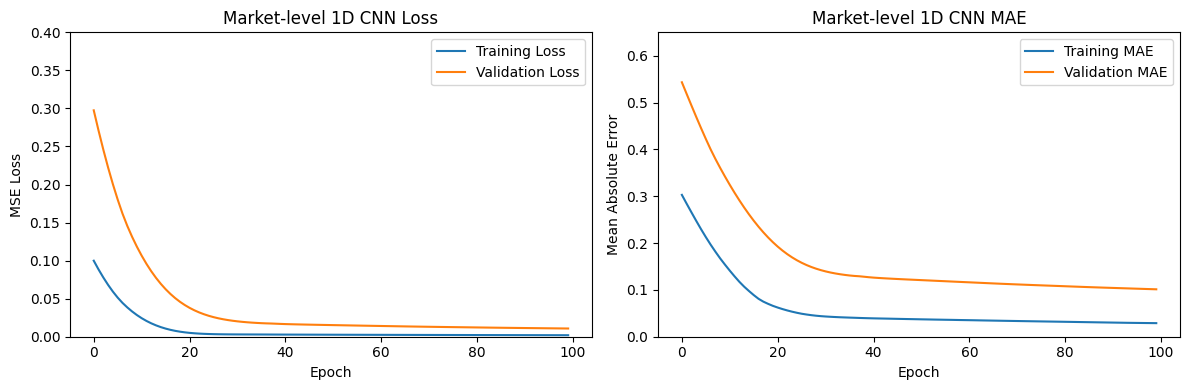

In [64]:
plot_training_curves(
    market_cnn_history,
    "Market-level 1D CNN"
)

Test data evaluation 1D CNN

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Market-level 1D CNN Train RMSE: 10858.95
Market-level 1D CNN Test RMSE: 27010.29


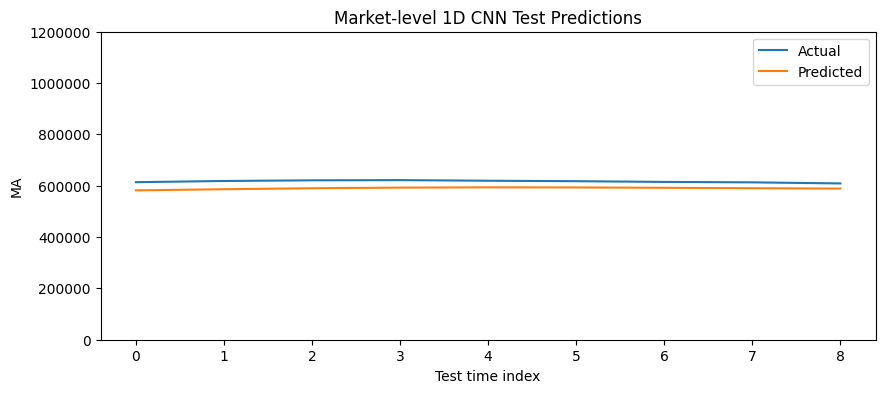

In [65]:
evaluate_and_plot(
    market_cnn_model,
    trainX_market,
    testX_market,
    trainY_market,
    testY_market,
    scaler_market,
    "Market-level 1D CNN"
)

### Comparison of RNN vs MLP vs 1D CNN

In [66]:
rnn_rmse, rnn_mae = evaluate_metrics(
    market_rnn_model,
    testX_market,
    testY_market,
    scaler_market
)

mlp_rmse, mlp_mae = evaluate_metrics(
    market_mlp_model,
    testX_market_mlp,
    testY_market,
    scaler_market
)

cnn_rmse, cnn_mae = evaluate_metrics(
    market_cnn_model,
    testX_market,
    testY_market,
    scaler_market
)

comparison = pd.DataFrame({
    "Model": ["RNN", "MLP", "1D CNN"],
    "RMSE": [rnn_rmse, mlp_rmse, cnn_rmse],
    "MAE": [rnn_mae, mlp_mae, cnn_mae]
})

comparison

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


,Model,RMSE,MAE
0,RNN,15985.009573,15295.126984
1,MLP,10526.726267,9675.571429
2,1D CNN,27010.294472,26676.703373


### Your Turn — Build and Compare RNN Models

Choose one or more coherent housing subgroups (for example, 3-bedroom houses) and build at least 3 meaningfully different RNN forecasting models. Evaluate each model using training/validation curves, held-out future test predictions, RMSE, and MAE, and record your observations in markdown cells throughout the notebook.

### Model Exploration Summary

Briefly summarize which subgroup(s) and model variations you explored, what changes appeared to improve or worsen forecasting performance, any patterns you noticed in the training curves or predictions, and which model you believe performed best and why.

Number of 3-bedroom house observations: 51
Date range: 2007-03-31 00:00:00 to 2019-09-30 00:00:00


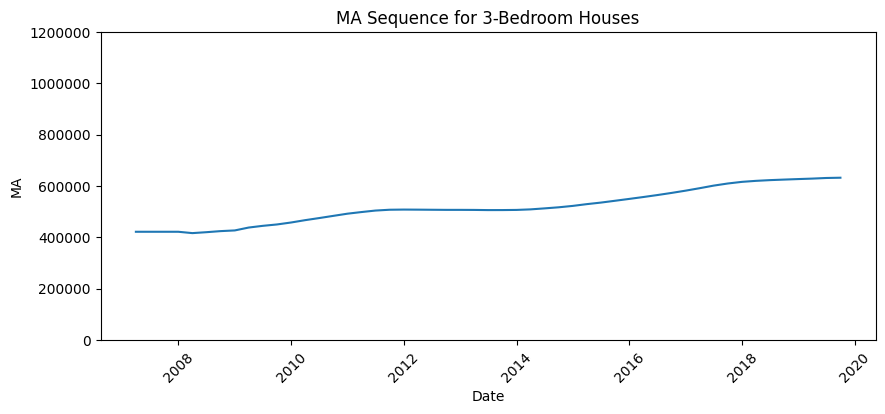

In [67]:

house_3bed = (
    house[
        (house["type"] == "house") &
        (house["bedrooms"] == 3)
    ]
    .sort_values("saledate")
    .reset_index(drop=True)
)

print("Number of 3-bedroom house observations:", len(house_3bed))
print("Date range:", house_3bed["saledate"].min(), "to", house_3bed["saledate"].max())

plt.figure(figsize=(10, 4))
plt.plot(
    house_3bed["saledate"],
    house_3bed["MA"]
)

plt.title("MA Sequence for 3-Bedroom Houses")
plt.xlabel("Date")
plt.ylabel("MA")
plt.ylim(0, 1200000)
plt.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=45)
plt.show()

In [68]:
df_3bed = house_3bed[["MA"]].copy()

scaler_3bed = MinMaxScaler(feature_range=(0, 1))
scaled_3bed = scaler_3bed.fit_transform(df_3bed)

look_back_3bed = 2                                           # same lookback used earlier in notebook

train_size_3bed = int(len(scaled_3bed) * 0.8)               # chronological 80/20 split

train_3bed = scaled_3bed[:train_size_3bed]                   # earlier historical data
test_3bed = scaled_3bed[train_size_3bed:]                    # held-out future data

trainX_3bed, trainY_3bed = create_sequences(
    train_3bed,
    look_back_3bed
)

testX_3bed, testY_3bed = create_sequences(
    test_3bed,
    look_back_3bed
)

print("trainX_3bed shape:", trainX_3bed.shape)
print("testX_3bed shape:", testX_3bed.shape)
print("Held-out future MA values used as prediction targets:")
print(
    house_3bed.iloc[train_size_3bed + look_back_3bed:][["saledate", "MA"]]
    .reset_index(drop=True)
)

trainX_3bed shape: (38, 2, 1)
testX_3bed shape: (9, 2, 1)
Held-out future MA values used as prediction targets:
    saledate      MA
0 2017-09-30  609355
1 2017-12-31  615743
2 2018-03-31  619638
3 2018-06-30  622466
4 2018-09-30  624602
5 2018-12-31  626608
6 2019-03-31  628423
7 2019-06-30  630814
8 2019-09-30  631875


Epoch 1/100


c:\Users\2003n\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 223ms/step - loss: 0.0016 - mean_absolute_error: 0.0316 - val_loss: 0.0028 - val_mean_absolute_error: 0.0501
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0010 - mean_absolute_error: 0.0283 - val_loss: 4.6608e-04 - val_mean_absolute_error: 0.0168
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 8.3130e-04 - mean_absolute_error: 0.0238 - val_loss: 0.0018 - val_mean_absolute_error: 0.0397
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 5.0512e-04 - mean_absolute_error: 0.0197 - val_loss: 0.0046 - val_mean_absolute_error: 0.0657
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 6.6898e-04 - mean_absolute_error: 0.0207 - val_loss: 0.0053 - val_mean_absolute_error: 0.0707
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 6.0866e-04 - mean_absolute_error: 0.0203 - val_loss: 0.0037 - val_mean_absolute_error: 0.0580
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 5.4187e-04 - mean_absolute_error: 0.0206 - va

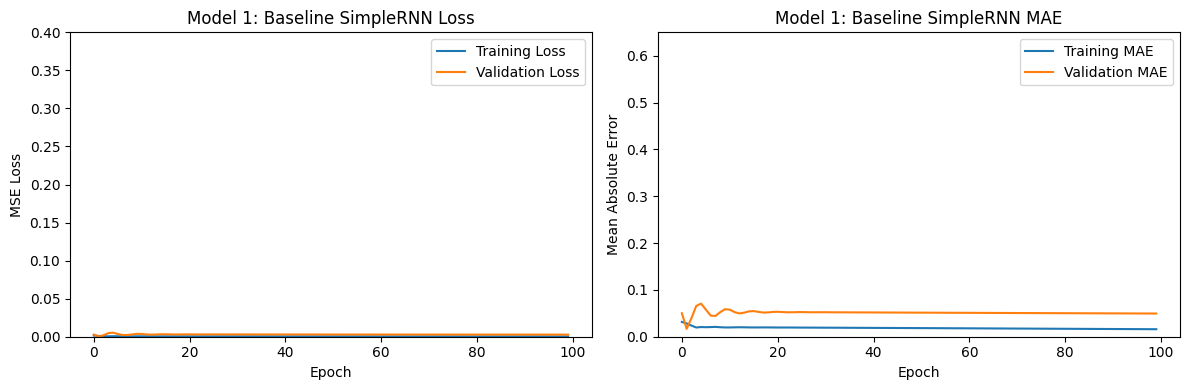

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Model 1: Baseline SimpleRNN Train RMSE: 6229.28
Model 1: Baseline SimpleRNN Test RMSE: 24012.82


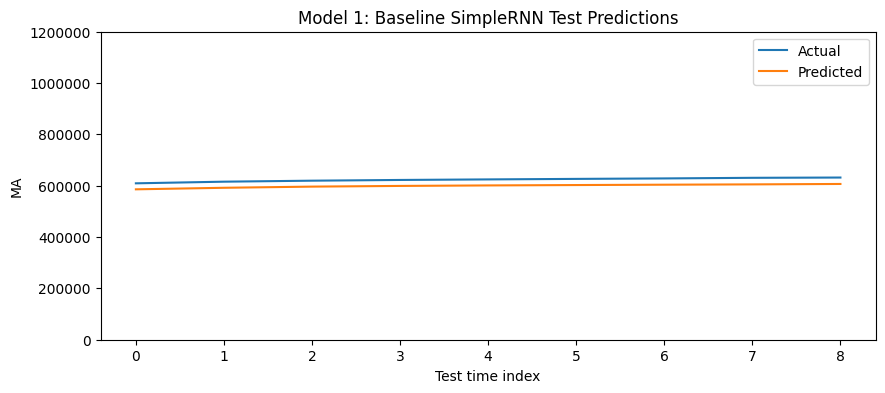

In [69]:

# Model 1: Baseline SimpleRNN

model_1 = Sequential([
    SimpleRNN(
        16,
        activation="tanh",
        input_shape=(look_back_3bed, trainX_3bed.shape[2])
    ),
    Dense(1)
])

model_1.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

history_1 = model_1.fit(
    trainX_3bed,
    trainY_3bed,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

plot_training_curves(
    history_1,
    "Model 1: Baseline SimpleRNN"
)

evaluate_and_plot(
    model_1,
    trainX_3bed,
    testX_3bed,
    trainY_3bed,
    testY_3bed,
    scaler_3bed,
    "Model 1: Baseline SimpleRNN"
)

Epoch 1/100


c:\Users\2003n\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 239ms/step - loss: 0.0216 - mean_absolute_error: 0.1316 - val_loss: 0.0346 - val_mean_absolute_error: 0.1831
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 7.7867e-04 - mean_absolute_error: 0.0209 - val_loss: 3.3903e-04 - val_mean_absolute_error: 0.0144
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0033 - mean_absolute_error: 0.0499 - val_loss: 0.0013 - val_mean_absolute_error: 0.0347
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0030 - mean_absolute_error: 0.0496 - val_loss: 1.4479e-04 - val_mean_absolute_error: 0.0103
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 6.6098e-04 - mean_absolute_error: 0.0209 - val_loss: 0.0034 - val_mean_absolute_error: 0.0556
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 5.1781e-04 - mean_absolute_error: 0.0187 - val_loss: 0.0092 - val_mean_absolute_error: 0.0938
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0010 - mean_absolute_error: 0.0291 - val_lo

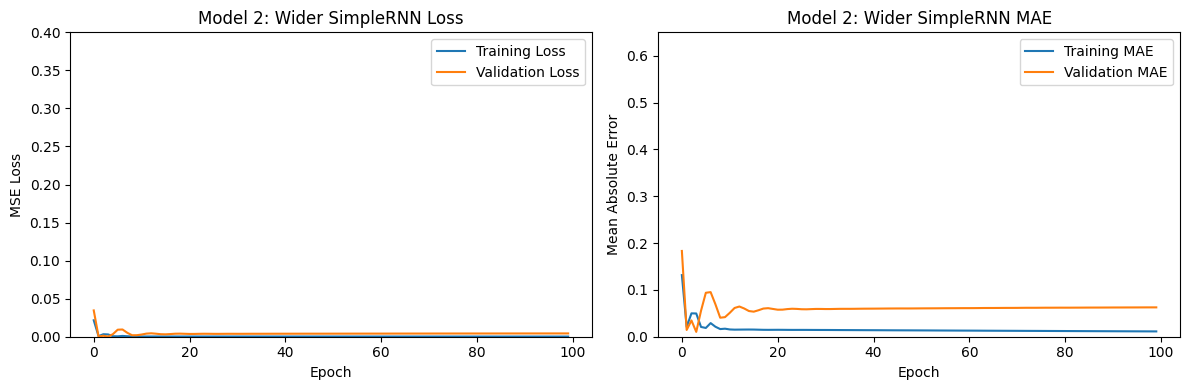

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
Model 2: Wider SimpleRNN Train RMSE: 7065.70
Model 2: Wider SimpleRNN Test RMSE: 27633.76


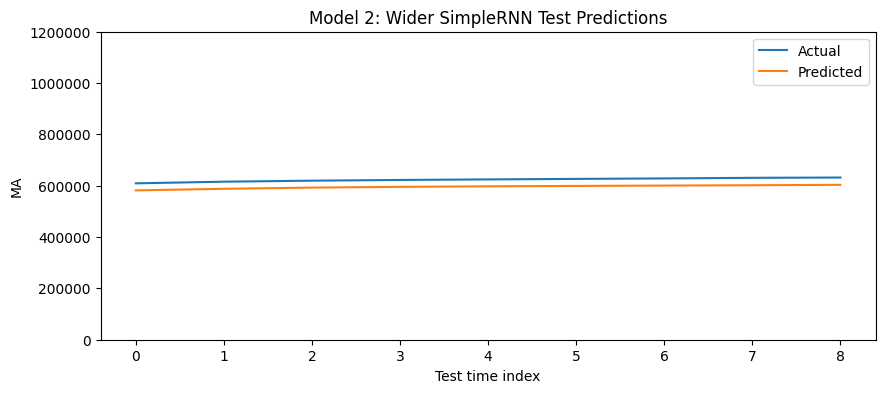

In [70]:

# Model 2: Wider SimpleRNN with additional Dense layer

model_2 = Sequential([
    SimpleRNN(
        32,
        activation="tanh",
        input_shape=(look_back_3bed, trainX_3bed.shape[2])
    ),
    Dense(
        16,
        activation="relu"
    ),
    Dense(1)
])

model_2.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

history_2 = model_2.fit(
    trainX_3bed,
    trainY_3bed,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

plot_training_curves(
    history_2,
    "Model 2: Wider SimpleRNN"
)

evaluate_and_plot(
    model_2,
    trainX_3bed,
    testX_3bed,
    trainY_3bed,
    testY_3bed,
    scaler_3bed,
    "Model 2: Wider SimpleRNN"
)

Epoch 1/100


c:\Users\2003n\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 209ms/step - loss: 0.0554 - mean_absolute_error: 0.2096 - val_loss: 0.0930 - val_mean_absolute_error: 0.3020
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0042 - mean_absolute_error: 0.0525 - val_loss: 1.8584e-04 - val_mean_absolute_error: 0.0112
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0115 - mean_absolute_error: 0.0925 - val_loss: 0.0100 - val_mean_absolute_error: 0.0999
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0075 - mean_absolute_error: 0.0795 - val_loss: 8.7048e-04 - val_mean_absolute_error: 0.0287
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0018 - mean_absolute_error: 0.0326 - val_loss: 0.0041 - val_mean_absolute_error: 0.0619
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0015 - mean_absolute_error: 0.0344 - val_loss: 0.0147 - val_mean_absolute_error: 0.1195
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0027 - mean_absolute_error: 0.0473 - val_loss: 0.0144 -

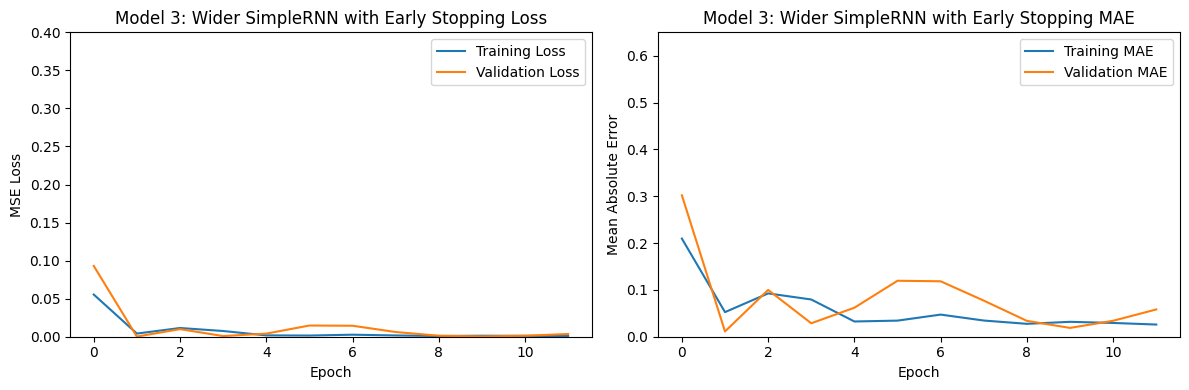

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Model 3: Wider SimpleRNN with Early Stopping Train RMSE: 10390.05
Model 3: Wider SimpleRNN with Early Stopping Test RMSE: 4479.77


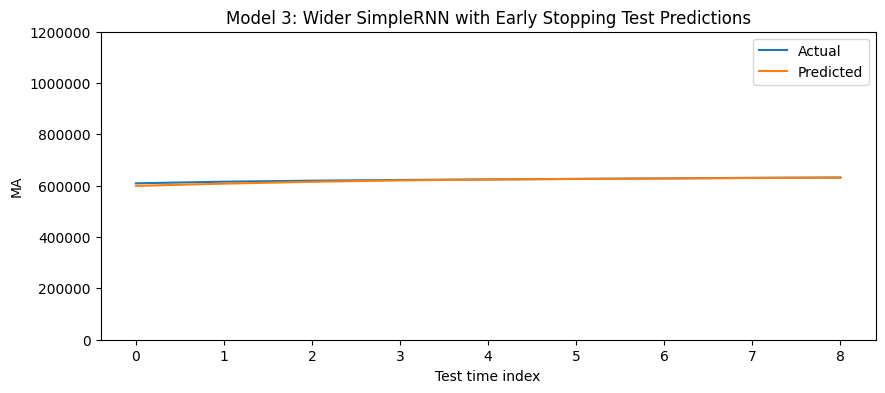

In [73]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",       # Watch validation loss
    patience=10,               # Stop after 10 epochs without improvement
    restore_best_weights=True, # Return to the best-performing epoch
    verbose=1
)

model_3 = Sequential([
    SimpleRNN(
        128,
        activation="tanh",
        input_shape=(look_back_3bed, trainX_3bed.shape[2])
    ),
    Dense(
        8,
        activation="relu"
    ),
    Dense(1)
])

model_3.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

history_3 = model_3.fit(
    trainX_3bed,
    trainY_3bed,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stopping],
    verbose=1
)

plot_training_curves(
    history_3,
    "Model 3: Wider SimpleRNN with Early Stopping"
)

evaluate_and_plot(
    model_3,
    trainX_3bed,
    testX_3bed,
    trainY_3bed,
    testY_3bed,
    scaler_3bed,
    "Model 3: Wider SimpleRNN with Early Stopping"
)

Model 1 served as the baseline SimpleRNN model. It achieved a test RMSE of 24,012.82 and generally followed the upward pattern of the actual housing prices. However, its predictions were consistently below the actual values, showing that the baseline model did not fully capture the price level in the test period.

Model 2 increased the width of the SimpleRNN architecture to test whether additional model capacity would improve the forecast. Instead, its test RMSE increased to 27,633.76, which was slightly worse than the baseline model. Although the predictions still followed the overall trend, increasing the number of RNN units alone did not improve generalization.

Model 3 used a wider SimpleRNN, an additional Dense layer, and early stopping. This model achieved the lowest test RMSE at 4,479.77, making it the best-performing model. Even though its training RMSE was higher than the other two models, its predictions were much closer to the actual test values. This suggests that early stopping prevented the model from training too long and overfitting the training data.

Overall, simply making the RNN wider did not improve forecasting performance. The most effective change was adding early stopping to the larger architecture, which reduced unnecessary training and significantly improved performance on unseen data. One limitation is that the test period is very small, so these results should be interpreted carefully. With more data, the models could be compared more reliably across a longer forecasting period.